# Modeling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
DATASET_PATH = "../data/1st_test/test_1_clean.csv"

In [3]:
df = pd.read_csv(DATASET_PATH)

In [4]:
bearing_1 = df[[column for column in df.columns if "bearing_1" in column]]
bearing_2 = df[[column for column in df.columns if "bearing_2" in column]]
bearing_3 = df[[column for column in df.columns if "bearing_3" in column]]
bearing_4 = df[[column for column in df.columns if "bearing_4" in column]]

In [5]:
FEATURES = ["mean_absolute", "std", "skewness", "kurtois", "rms", "crest_factor"]
AXES = ["x", "y"]

new_columns = []
for ax in AXES:
    for feature in FEATURES:
        new_columns.append(f"({ax})_{feature}")

In [6]:
bearing_1.columns = new_columns
bearing_2.columns = new_columns
bearing_3.columns = new_columns
bearing_4.columns = new_columns

In [7]:
healthy_df = pd.concat([bearing_1, bearing_2])

In [8]:
healthy_df.head(5)

,(x)_mean_absolute,(x)_std,(x)_skewness,(x)_kurtois,(x)_rms,(x)_crest_factor,(y)_mean_absolute,(y)_std,(y)_skewness,(y)_kurtois,(y)_rms,(y)_crest_factor
0,0.104144,0.081122,-0.029993,1.069163,0.124614,5.777850,0.100250,0.070648,0.220116,3.065884,0.117493,5.966305
1,0.103652,0.079515,-0.070075,1.161552,0.123811,5.282236,0.099853,0.069529,0.126498,2.001016,0.116833,4.972931
2,0.105036,0.080217,-0.041646,0.986286,0.125246,4.974196,0.101540,0.069464,0.151050,1.968951,0.118384,4.637434
3,0.104898,0.080825,0.005162,1.034294,0.125197,4.776455,0.101570,0.071265,0.099494,1.745370,0.119005,4.495626
4,0.104776,0.082034,-0.060196,1.110164,0.125618,4.959475,0.102188,0.072153,0.095884,1.181160,0.119688,4.486647


### I. Anomaly Detection

In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()
healthy_df_scaled = scaler.fit_transform(healthy_df)

In [11]:
ad_model = IsolationForest(
    n_estimators = 200,
    max_samples = "auto",
    contamination = 0.01,
    max_features = 1.0,
    random_state = None
)

ad_model.fit(healthy_df_scaled)

IsolationForest(contamination=0.01, n_estimators=200)

In [12]:
bearing_3_scaled = scaler.transform(bearing_3)

bearing_3_score = ad_model.decision_function(bearing_3_scaled)
bearing_3_prediction = ad_model.predict(bearing_3_scaled)
bearing_3_prediction = pd.DataFrame({
    "score": bearing_3_score,
    "prediction": bearing_3_prediction
})

bearing_3_prediction.head()

,score,prediction
0,0.024611,1
1,0.098092,1
2,0.074930,1
3,0.094951,1
4,0.079490,1


In [13]:
bearing_3_prediction["prediction"].value_counts()

prediction
 1    1775
-1     381
Name: count, dtype: int64

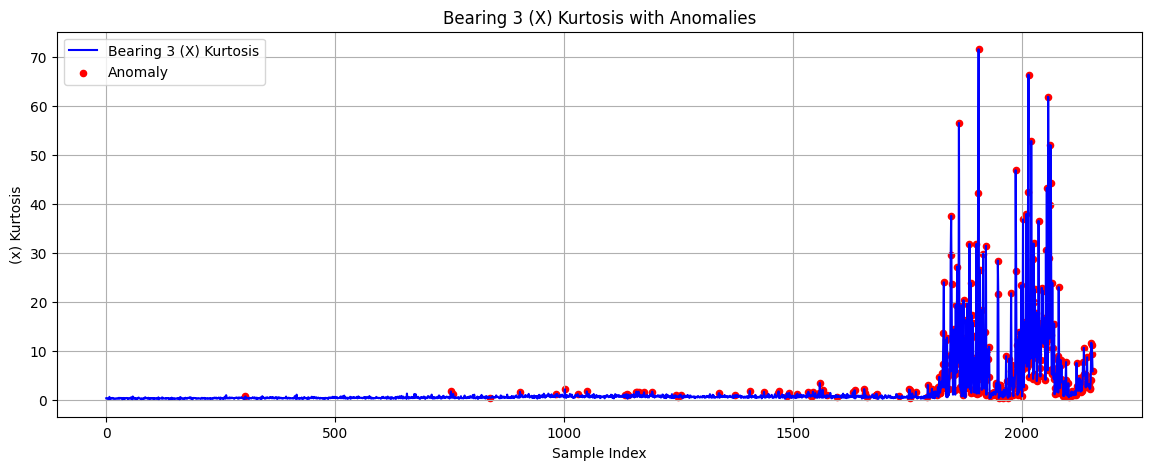

In [14]:
plt.figure(figsize = (14, 5))
plt.plot(bearing_3["(x)_kurtois"], label = "Bearing 3 (X) Kurtosis", color = "blue")

anomaly_indices = bearing_3_prediction[bearing_3_prediction["prediction"] == -1].index
anomaly_values = bearing_3.loc[anomaly_indices, "(x)_kurtois"]

plt.scatter(anomaly_indices, anomaly_values, color = "red", label = "Anomaly", s = 20)

plt.xlabel('Sample Index')
plt.ylabel('(x) Kurtosis')
plt.title('Bearing 3 (X) Kurtosis with Anomalies')
plt.legend()
plt.grid(True)
plt.show()

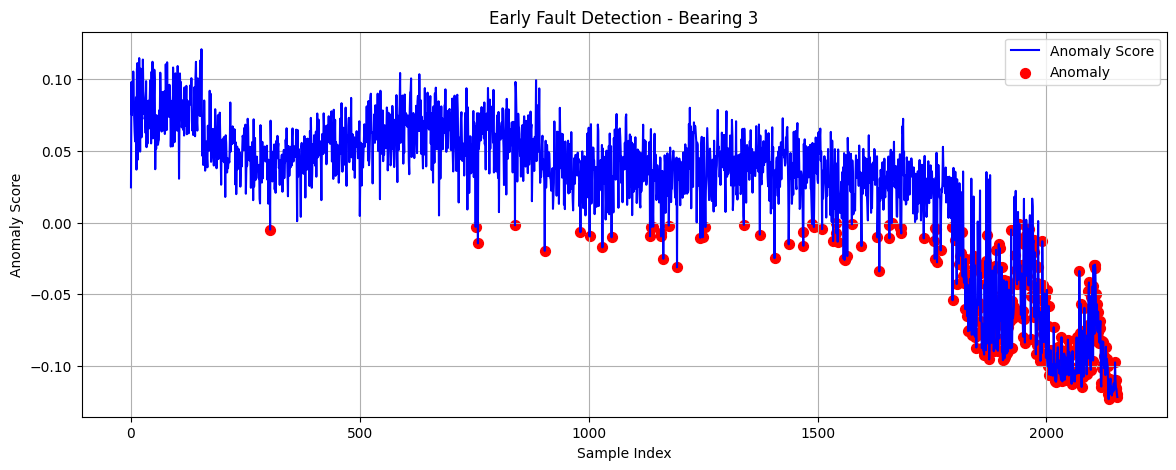

In [15]:
plt.figure(figsize = (14, 5))

plt.plot(bearing_3_prediction["score"], label = "Anomaly Score", color = "blue")

plt.scatter(
    np.where(bearing_3_prediction["prediction"] == -1),
    bearing_3_prediction["score"][bearing_3_prediction["prediction"] == -1],
    color = "red",
    label = "Anomaly",
    s = 50
)

plt.xlabel("Sample Index")
plt.ylabel("Anomaly Score")
plt.title("Early Fault Detection - Bearing 3")
plt.legend()
plt.grid(True)
plt.show()

### II. RUL (Bearing 3 Specific)

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import tensorflow as tf

In [17]:
num_failures = len(bearing_3)
failure_file_index = 1800

rul = np.array([failure_file_index - i for i in range(failure_file_index)])
rul = np.append(rul, 0)

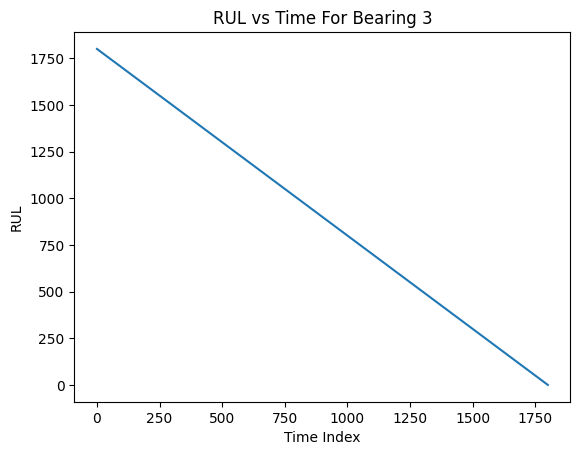

In [18]:
plt.plot(rul)
plt.xlabel("Time Index")
plt.ylabel("RUL")
plt.title("RUL vs Time For Bearing 3")
plt.show()

In [19]:
X = bearing_3.iloc[:failure_file_index, :]
y = rul[:failure_file_index]

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
def create_sequences(X, y, window_size = 20):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i: i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

In [22]:
window_size = 30
X_seq, y_seq = create_sequences(X_scaled, rul, window_size)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, shuffle = False, test_size = 0.25)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, shuffle = False, test_size = 0.5)

In [32]:
rul_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(64, input_shape = (window_size, X_seq.shape[2]), return_sequences = False),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation = "relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32, activation = "relu"),
    tf.keras.layers.Dense(1)
])

In [33]:
rul_model.compile(optimizer = "adam", loss = "mse")

In [34]:
history = rul_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 100,
    batch_size = 16,
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor = "val_loss", 
            patience = 10, 
            restore_best_weights = True
        )
    ]
)

Epoch 1/100
83/83 [==============================] - 2s 10ms/step - loss: 1357074.0000 - val_loss: 113611.4375
Epoch 2/100
83/83 [==============================] - 0s 5ms/step - loss: 1275720.8750 - val_loss: 101214.4062
Epoch 3/100
83/83 [==============================] - 0s 5ms/step - loss: 1102250.1250 - val_loss: 81529.6406
Epoch 4/100
83/83 [==============================] - 0s 5ms/step - loss: 839135.1875 - val_loss: 59075.6367
Epoch 5/100
83/83 [==============================] - 0s 5ms/step - loss: 600682.5625 - val_loss: 54593.4531
Epoch 6/100
83/83 [==============================] - 0s 5ms/step - loss: 303531.3438 - val_loss: 22805.3320
Epoch 7/100
83/83 [==============================] - 0s 5ms/step - loss: 268541.2812 - val_loss: 8993.9287
Epoch 8/100
83/83 [==============================] - 0s 5ms/step - loss: 324879.1562 - val_loss: 14224.7402
Epoch 9/100
83/83 [==============================] - 0s 5ms/step - loss: 173813.8281 - val_loss: 81071.0312
Epoch 10/100
83/83 [===

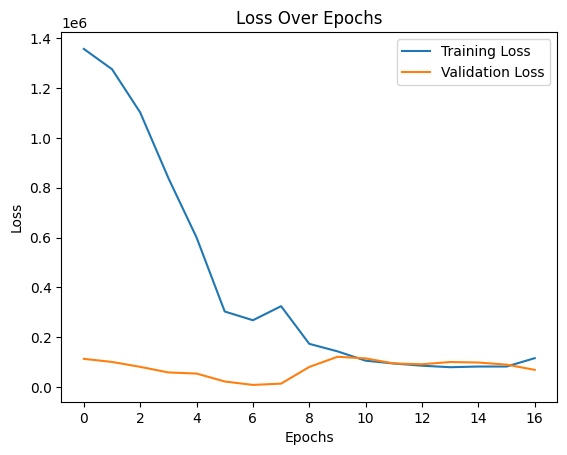

In [40]:
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()
plt.show()

In [36]:
y_pred = rul_model.predict(X_test)

7/7 [==============================] - 0s 4ms/step


In [38]:
root_mean_squared_error(y_test, y_pred)

168.53118338986442

$$
\text{Error Percentage} = \frac{\text{RMSE}}{\text{Max RUL}} \times 100 = \frac{168.5}{1800} \times 100 \approx 9.36\%
$$